In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [30]:
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Extra\WGI_master_panel_final.xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Set panel index directly
df = df.set_index(['country', 'year'])

# Sort index (important for panel models)
df = df.sort_index()

print(df.head())

                  control of corruption  rule of law  \
country     year                                       
afghanistan 2004                    0.0        0.075   
            2005                    0.0        0.075   
            2006                    0.0        0.025   
            2007                    NaN          NaN   
            2008                    NaN          NaN   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2004                      0.25               0.1875   
            2005                      0.25               0.0625   
            2006                      0.00               0.0625   
            2007                       NaN                  NaN   
            2008                       NaN                  NaN   

                  voice and accountability  regulatory quality  attacks  
country     year                                               

In [31]:
# Log transform (must for terrorism data)
df['log_attacks'] = np.log1p(df['attacks'])

# Lag variable (within each country)
df['lag_attacks'] = df.groupby(level=0)['log_attacks'].shift(1)

# Drop NA from lag
df = df.dropna()
df.head()

control of corruption  rule of law  \
country     year                                       
afghanistan 2005                    0.0        0.075   
            2006                    0.0        0.025   
            2009                    0.0        0.075   
            2010                    0.0        0.075   
            2011                    0.0        0.075   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2005                      0.25               0.0625   
            2006                      0.00               0.0625   
            2009                      0.00               0.1250   
            2010                      0.00               0.1250   
            2011                      0.00               0.1250   

                  voice and accountability  regulatory quality  attacks  \
country     year                                                          
afghanistan 2005                  0.000000            0.107143    155.0   
            2006                  0.102000            0.107143    283.0   
            2009                  0.100667            0.107143    503.0   
            2010                  0.082667            0.107143    542.0   
            2011                  0.082667            0.107143    421.0   

                  log_attacks  lag_attacks  
country     year                            
afghanistan 2005     5.049856     4.488636  
            2006     5.648974     5.049856  
            2009     6.222576     6.028279  
            2010     6.297109     6.222576  
            2011     6.045005     6.297109

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [33]:
#(A) Normality Test (Shapiro / Jarque-Bera)

variables = ['log_attacks', 'rule of law', 'control of corruption',
             'voice and accountability', 'regulatory quality',
             'government effectiveness', 'political stability']

for var in variables:
    stat, p = stats.shapiro(df[var].dropna())
    print(f"{var}: Shapiro p-value = {p}")

log_attacks: Shapiro p-value = 2.2201791832085616e-52
rule of law: Shapiro p-value = 6.496106520161128e-27
control of corruption: Shapiro p-value = 2.704498926764265e-37
voice and accountability: Shapiro p-value = 4.817424382111462e-22
regulatory quality: Shapiro p-value = 4.796463884365639e-21
government effectiveness: Shapiro p-value = 9.583444644639285e-41
political stability: Shapiro p-value = 2.185443057951706e-19


In [34]:
#(B) Correlation Significance (Pearson Test)

for var in variables[1:]:
    corr, p = stats.pearsonr(df['log_attacks'], df[var])
    print(f"log_attacks vs {var}: Corr={corr:.3f}, p={p:.5f}")

log_attacks vs rule of law: Corr=-0.169, p=0.00000
log_attacks vs control of corruption: Corr=-0.164, p=0.00000
log_attacks vs voice and accountability: Corr=-0.144, p=0.00000
log_attacks vs regulatory quality: Corr=-0.143, p=0.00000
log_attacks vs government effectiveness: Corr=-0.051, p=0.00982
log_attacks vs political stability: Corr=-0.340, p=0.00000


       control of corruption  rule of law  government effectiveness  \
count            2600.000000  2600.000000               2600.000000   
mean                0.329712     0.480510                  0.353173   
std                 0.269742     0.241866                  0.285928   
min                 0.000000     0.025000                  0.000000   
25%                 0.125000     0.300000                  0.250000   
50%                 0.250000     0.425000                  0.250000   
75%                 0.500000     0.650000                  0.500000   
max                 1.000000     1.000000                  1.000000   

       political stability  voice and accountability  regulatory quality  \
count          2600.000000               2600.000000         2600.000000   
mean              0.558882                  0.467540            0.496484   
std               0.244107                  0.260718            0.224479   
min               0.000000                  0.000000    

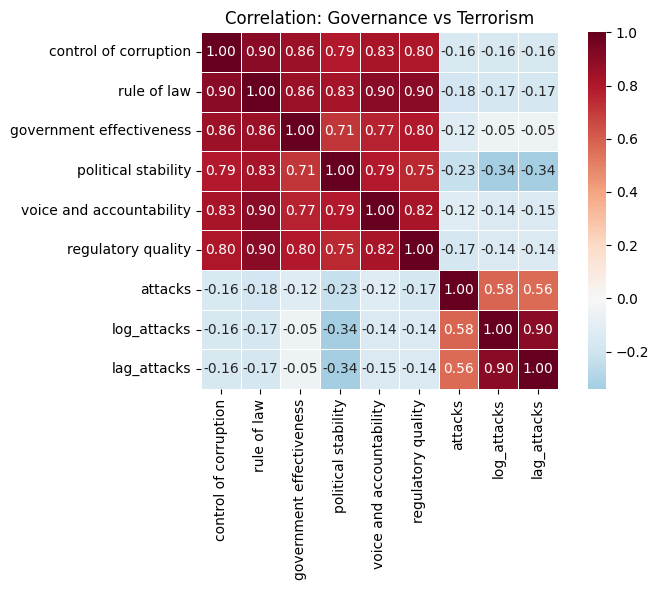

In [35]:
print(df.describe())

# Correlation heatmap
cols = [
    "control of corruption",
    "rule of law",
    "government effectiveness",
    "political stability",
    "voice and accountability",
    "regulatory quality",
    "attacks",
    "log_attacks",
    "lag_attacks"
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation: Governance vs Terrorism")
plt.tight_layout()
plt.show()

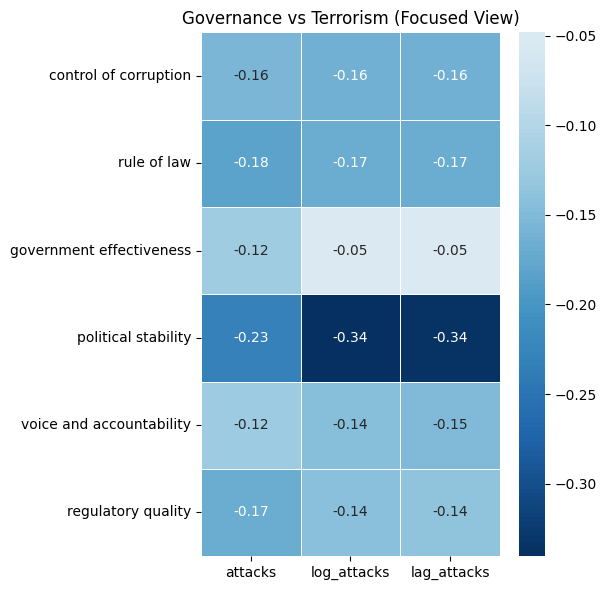

In [36]:
# Separate governance vs terrorism variables
gov_cols = [
    'control of corruption',
    'rule of law',
    'government effectiveness',
    'political stability',
    'voice and accountability',
    'regulatory quality'
]

target_cols = ['attacks','log_attacks', 'lag_attacks']

# Compute cross-correlation only
corr_matrix = df[gov_cols + target_cols].corr().loc[gov_cols, target_cols]

plt.figure(figsize=(6,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Governance vs Terrorism (Focused View)")
plt.tight_layout()
plt.show()

In [37]:
X = df[[
    "control of corruption",
    "rule of law",
    "government effectiveness",
    "political stability",
    "voice and accountability",
    "regulatory quality"
]]

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

                   Variable        VIF
0                     const   9.690027
1     control of corruption   6.566870
2               rule of law  14.154400
3  government effectiveness   4.636356
4       political stability   3.452504
5  voice and accountability   5.391366
6        regulatory quality   5.286918


In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gov_vars = df[['control of corruption','rule of law','government effectiveness',
               'political stability','voice and accountability','regulatory quality']]

scaler = StandardScaler()
gov_scaled = scaler.fit_transform(gov_vars)

pca = PCA(n_components=1)
df['governance_index'] = pca.fit_transform(gov_scaled)
print(pca.explained_variance_ratio_)

loadings = pd.DataFrame(pca.components_.T, 
                        columns=['PC1'], 
                        index=gov_vars.columns)
print(loadings)

[0.85158379]
                               PC1
control of corruption     0.414154
rule of law               0.431310
government effectiveness  0.399654
political stability       0.388951
voice and accountability  0.408568
regulatory quality        0.405604


In [39]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_[0])

loadings['abs_loading'] = loadings['PC1'].abs()
loadings = loadings.sort_values(by='abs_loading', ascending=False)
print(loadings)

Explained Variance Ratio: 0.8515837891449871
                               PC1  abs_loading
rule of law               0.431310     0.431310
control of corruption     0.414154     0.414154
voice and accountability  0.408568     0.408568
regulatory quality        0.405604     0.405604
government effectiveness  0.399654     0.399654
political stability       0.388951     0.388951


Principal Component Analysis (PCA) was applied to six World Governance Indicators to construct a composite governance index. The first principal component explained 85.16% of the total variance, indicating a strong common underlying factor. All indicators exhibited positive and nearly equal loadings (ranging from 0.389 to 0.431), suggesting that each dimension contributes uniformly to governance quality. Therefore, the first principal component was retained as a robust measure of overall governance.

In [40]:
import numpy as np

df=df.reset_index()

# sort before lagging
df = df.sort_values(['country', 'year'])

# create lags (panel-wise)
df['log_attack_lag1'] = df.groupby('country')['log_attacks'].shift(1)
df['log_attack_lag2'] = df.groupby('country')['log_attacks'].shift(2)

# drop missing values from lagging
df = df.dropna()

df = df.set_index(['country', 'year'])
df.head()

control of corruption  rule of law  \
country     year                                       
afghanistan 2009                    0.0        0.075   
            2010                    0.0        0.075   
            2011                    0.0        0.075   
            2012                    0.0        0.075   
            2013                    0.0        0.075   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2009                       0.0                0.125   
            2010                       0.0                0.125   
            2011                       0.0                0.125   
            2012                       0.0                0.125   
            2013                       0.0                0.125   

                  voice and accountability  regulatory quality  attacks  \
country     year                                                          
afghanistan 2009                  0.100667            0.107143    503.0   
            2010                  0.082667            0.107143    542.0   
            2011                  0.082667            0.107143    421.0   
            2012                  0.082667            0.107143   1469.0   
            2013                  0.082667            0.107143   1443.0   

                  log_attacks  lag_attacks  governance_index  log_attack_lag1  \
country     year                                                                
afghanistan 2009     6.222576     6.028279         -3.693459         5.648974   
            2010     6.297109     6.222576         -3.721672         6.222576   
            2011     6.045005     6.297109         -3.721672         6.297109   
            2012     7.293018     6.045005         -3.721672         6.045005   
            2013     7.275172     7.293018         -3.721672         7.293018   

                  log_attack_lag2  
country     year                   
afghanistan 2009         5.049856  
            2010         5.648974  
            2011         6.222576  
            2012         6.297109  
            2013         6.045005

In [41]:
#(C) Mean Difference Test (Optional – High vs Low Governance)

df['gov_dummy'] = np.where(df['governance_index'] > df['governance_index'].median(), 1, 0)

group1 = df[df['gov_dummy'] == 1]['log_attacks']
group0 = df[df['gov_dummy'] == 0]['log_attacks']

t_stat, p_val = stats.ttest_ind(group1, group0)
print("T-test p-value:", p_val)

T-test p-value: 3.204275432013622e-21


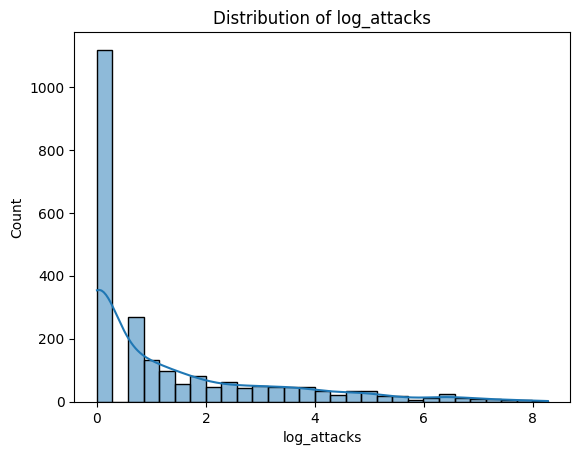

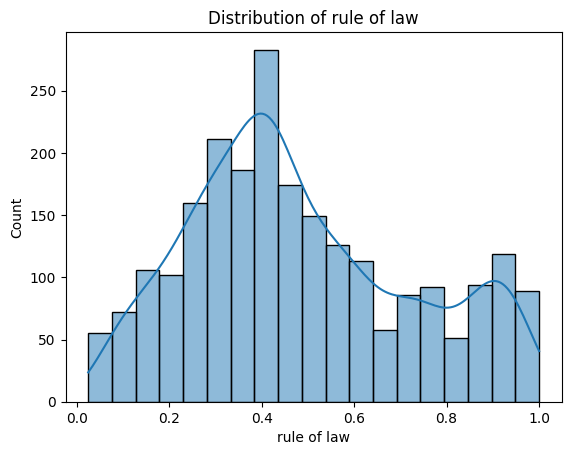

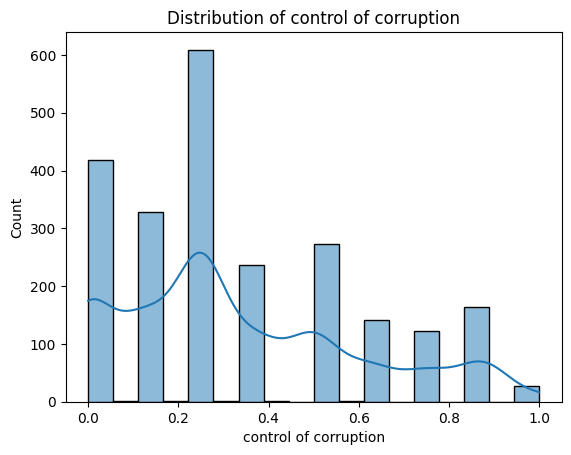

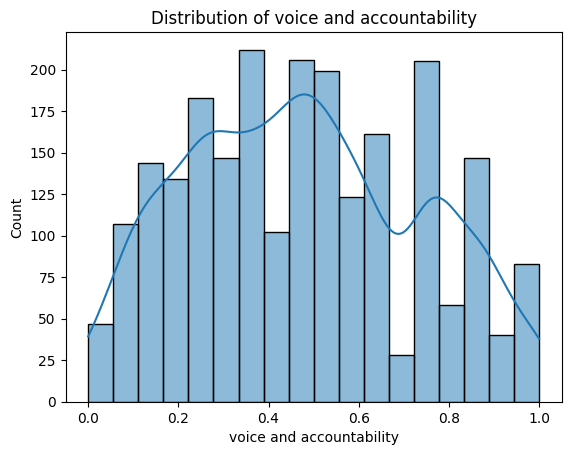

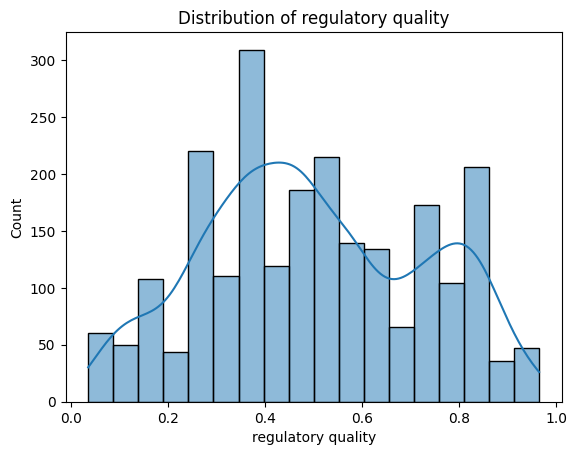

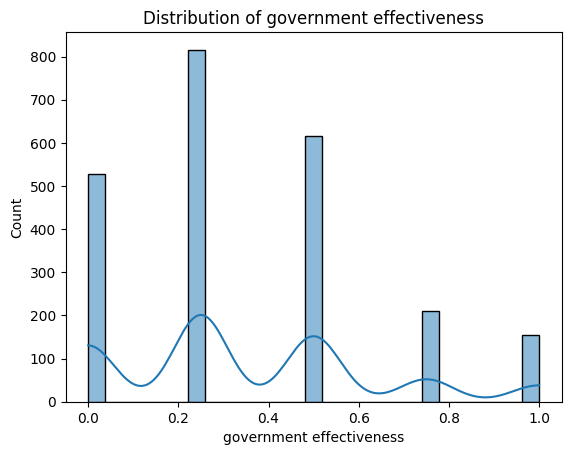

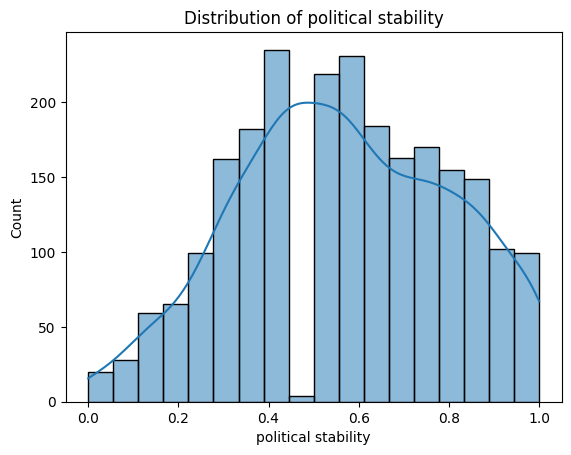

In [42]:
#3. Visualizations for Inferential Analysis

#Distribution PLots
for var in variables:
    plt.figure()
    sns.histplot(df[var], kde=True)
    plt.title(f"Distribution of {var}")
    plt.show()

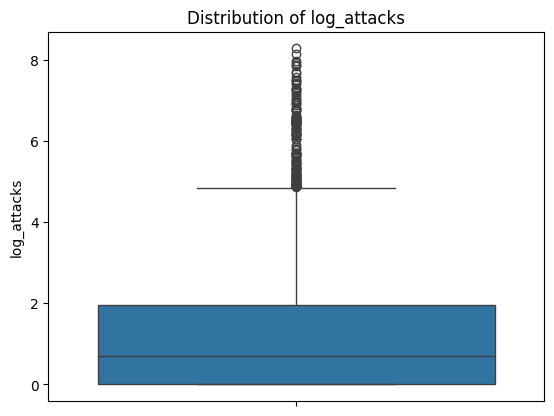

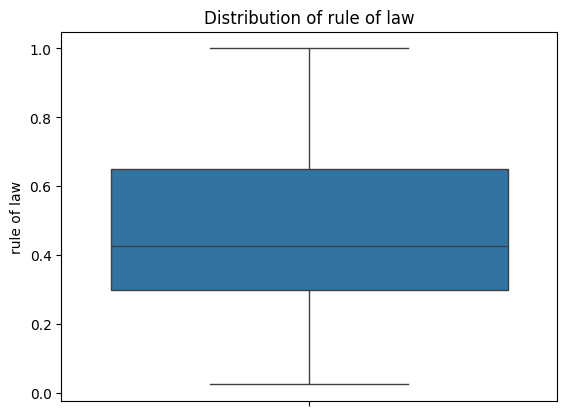

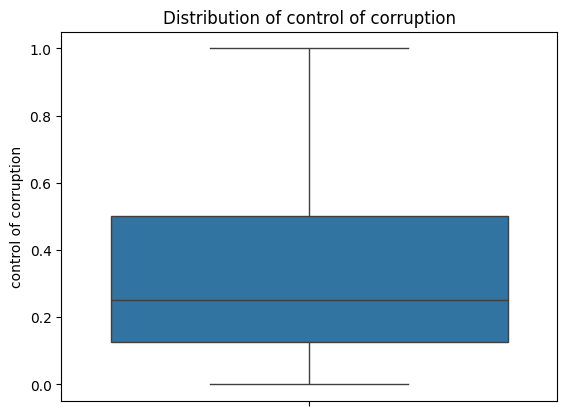

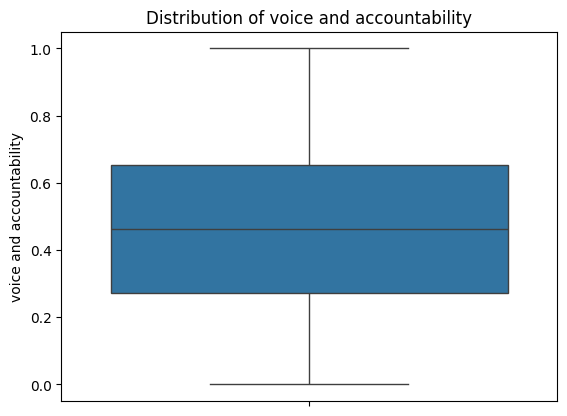

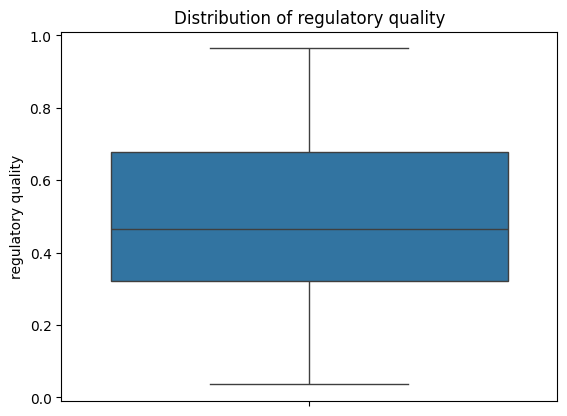

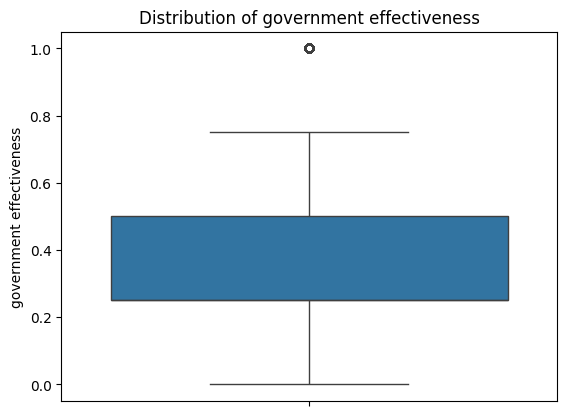

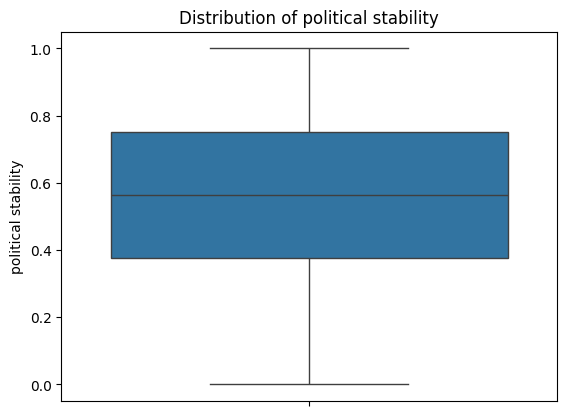

In [56]:
#Boxplots
for var in variables:
    plt.figure()
    sns.boxplot(df[var])
    plt.title(f"Distribution of {var}")
    plt.show()

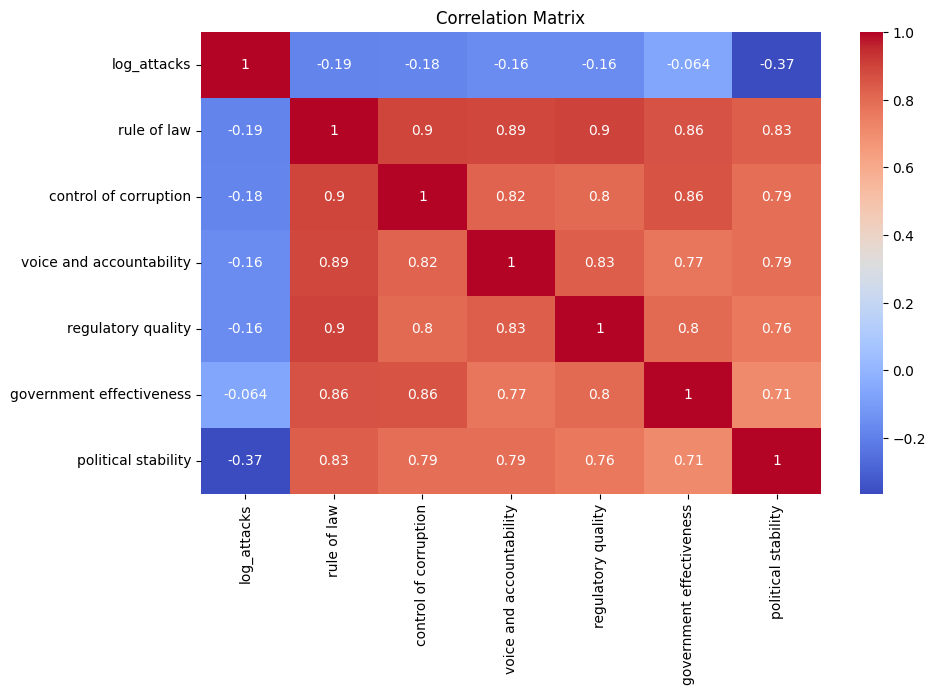

In [44]:
#correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[variables].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

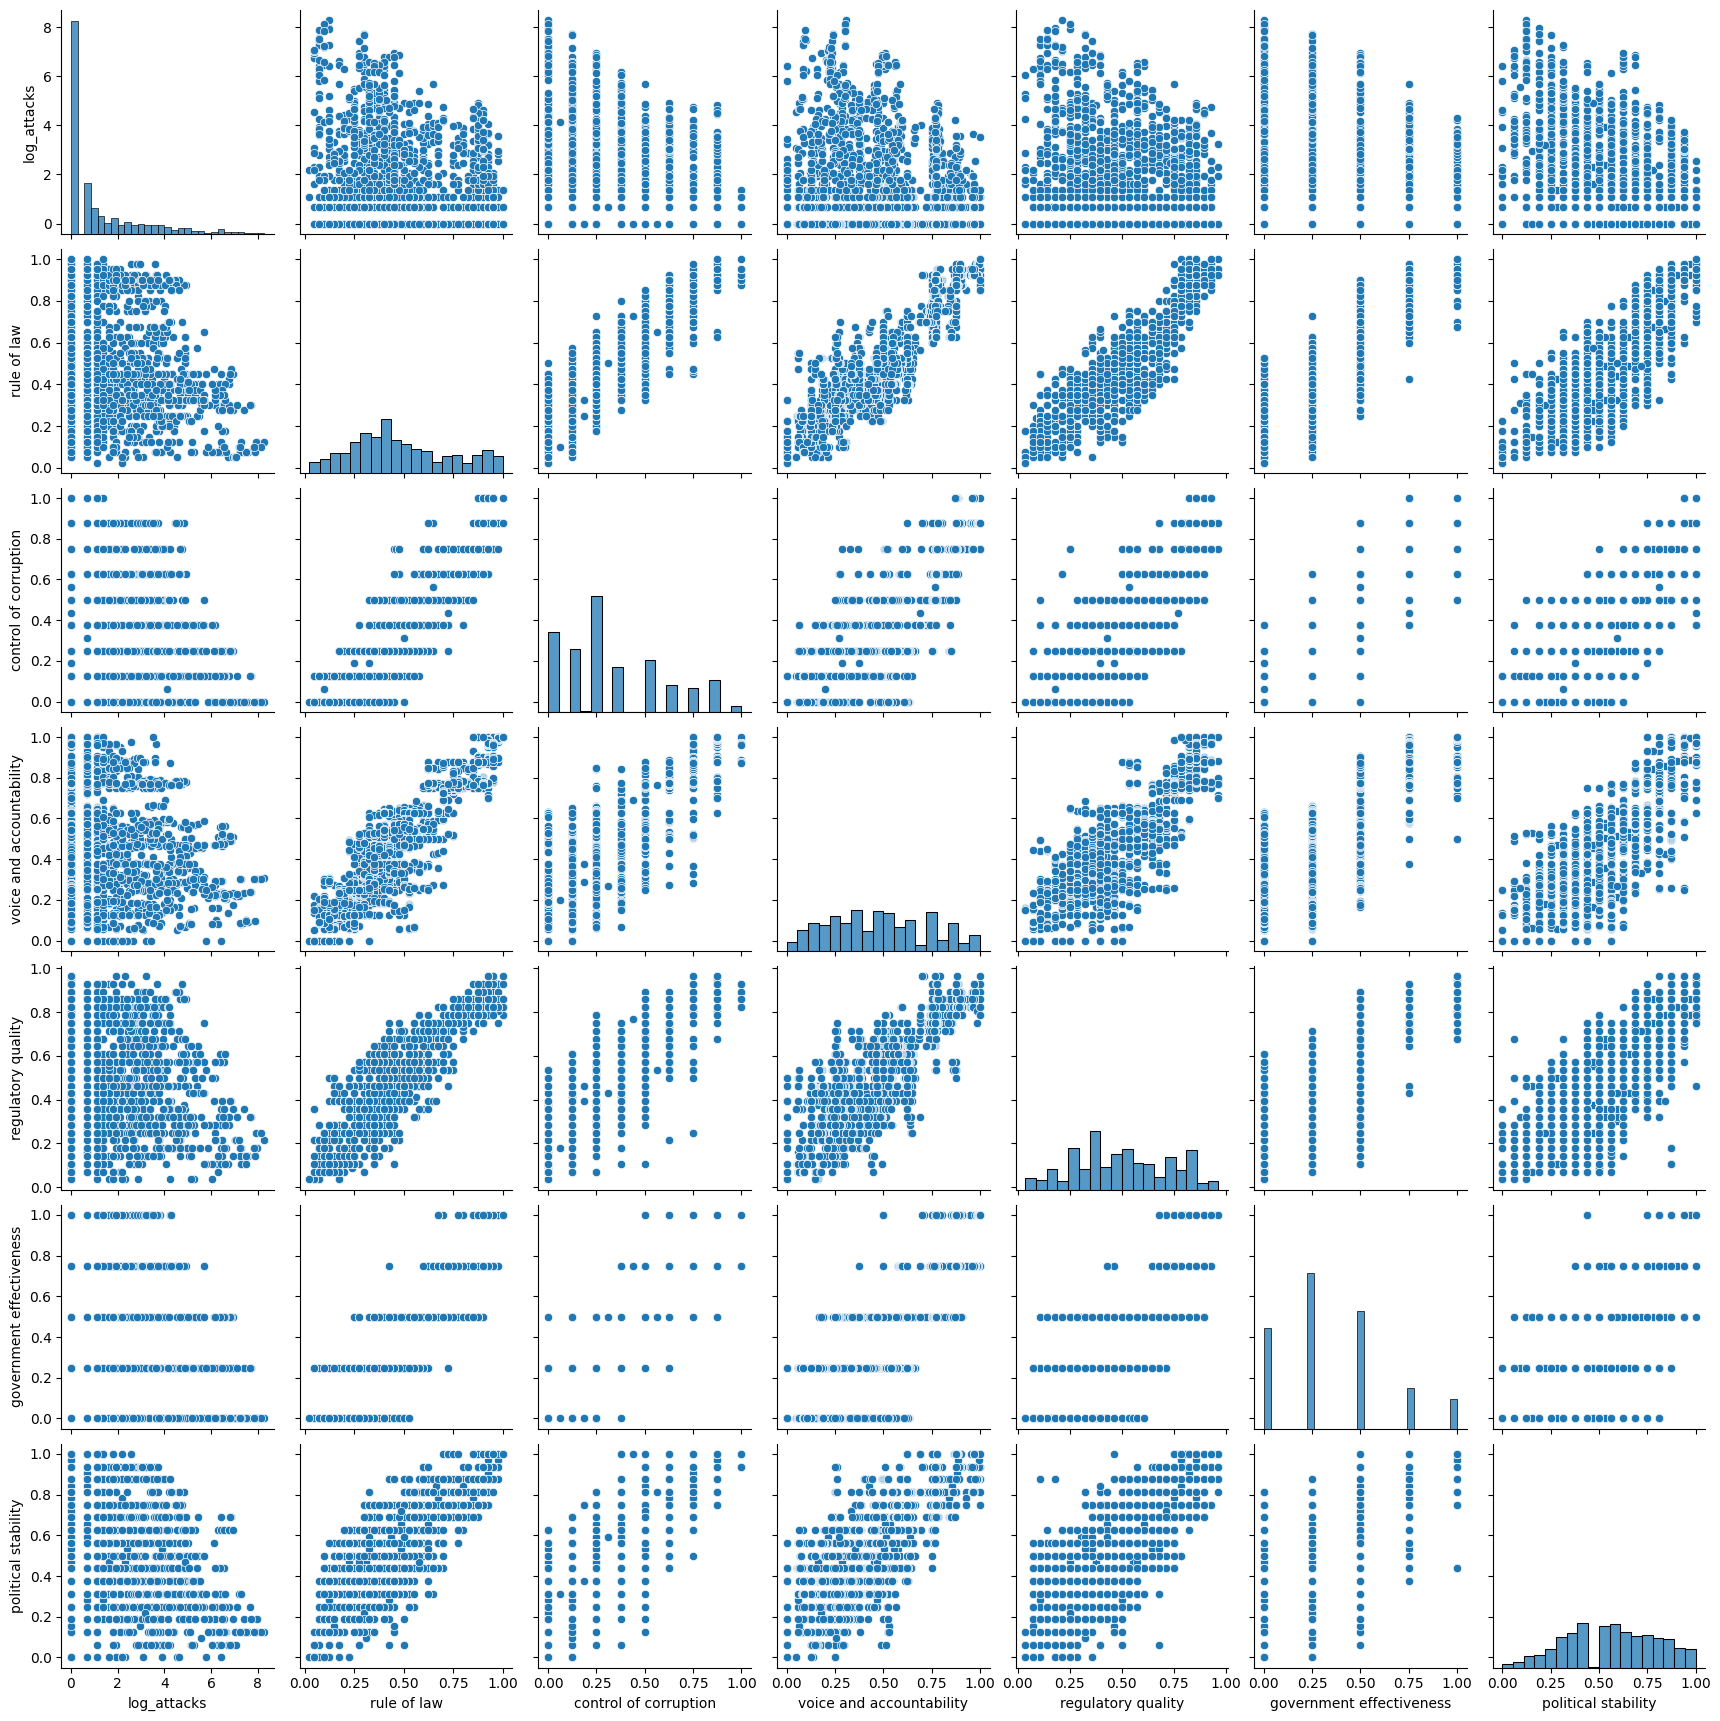

In [45]:
#Pairplots
sns.pairplot(df[variables])
plt.show()

MODEL 1: All 6 Variables + Dynamic Lags

In [46]:
#4. Regression Model (Simple OLS for Visualization Purpose)

X = df[['rule of law', 'control of corruption',
        'voice and accountability', 'regulatory quality',
        'government effectiveness', 'political stability']]

X = sm.add_constant(X)
y = df['log_attacks']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_attacks   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     109.7
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.72e-122
Time:                        04:39:02   Log-Likelihood:                -4345.8
No. Observations:                2326   AIC:                             8706.
Df Residuals:                    2319   BIC:                             8746.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [47]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

#Define Variables
X_6 = df[['log_attack_lag1', 'log_attack_lag2',
          'rule of law','control of corruption','voice and accountability',
          'regulatory quality','government effectiveness','political stability']]

y = df['log_attacks']

#Fixed Effects (Dynamic Panel)
model_fe_6 = PanelOLS(y, X_6, entity_effects=True)
fe_results_6 = model_fe_6.fit(cov_type='clustered', cluster_entity=True)

print(fe_results_6.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:            log_attacks   R-squared:                        0.4373
Estimator:                   PanelOLS   R-squared (Between):              0.8908
No. Observations:                2326   R-squared (Within):               0.4373
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.8221
Time:                        04:39:02   Log-likelihood                   -2292.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      211.85
Entities:                         137   P-value                           0.0000
Avg Obs:                       16.978   Distribution:                  F(8,2181)
Min Obs:                       9.0000                                           
Max Obs:                       19.000   F-statistic (robust):             85.419
                            

1. Moderate Within-Country Explanatory Power
The model explains 37.6% of within-country variation (Within R² = 0.3761), indicating a moderate ability to capture temporal dynamics in terrorism.
Lower Between R² (0.7832) compared to Random Effects suggests reduced emphasis on cross-country variation, which is expected under Fixed Effects.

2. Strong Persistence in Terrorism Dynamics
log_attack_lag1 (0.4726) and log_attack_lag2 (0.1362) are positive and highly significant (p < 0.001).
Confirms path dependency, with past attacks influencing current levels, though with smaller magnitudes than Random Effects—indicating more reliable within-country estimates.

3. Limited Significance of Governance Indicators
Most governance variables (rule of law, corruption, voice, regulatory quality, government effectiveness) are statistically insignificant.
Suggests that short-term within-country changes in governance do not significantly affect terrorism in this specification.

4. Political Stability as a Key Determinant
Political stability (-1.4671, p < 0.001) is negative and highly significant.
Indicates that improvements in political stability substantially reduce terrorism, making it the only robust governance-related predictor in this model.

5. Model Validity and Econometric Implications
F-test for poolability (p < 0.001) confirms the presence of significant country-specific effects, justifying the use of Fixed Effects.
Use of clustered standard errors improves robustness.
However, potential issues remain:
Multicollinearity among governance variables
Endogeneity due to lagged dependent variables
Need for dynamic panel methods (e.g., GMM) for more consistent estimation.

In [48]:
#Random Effects
model_re_6 = RandomEffects(y, X_6)
re_results_6 = model_re_6.fit()

print(re_results_6.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:            log_attacks   R-squared:                        0.8971
Estimator:              RandomEffects   R-squared (Between):              0.9938
No. Observations:                2326   R-squared (Within):               0.3701
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.8971
Time:                        04:39:03   Log-likelihood                   -2480.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2526.4
Entities:                         137   P-value                           0.0000
Avg Obs:                       16.978   Distribution:                  F(8,2318)
Min Obs:                       9.0000                                           
Max Obs:                       19.000   F-statistic (robust):             2526.4
                            

1. Strong Model Fit with Cross-Sectional Dominance
The model explains a substantial proportion of variation (R² = 0.908).
Extremely high Between R² (0.9934) vs low Within R² (0.2768) indicates the model primarily captures cross-country differences rather than within-country temporal changes.

2. High Persistence in Terrorism Dynamics
Both lag variables are positive and highly significant.
This confirms that terrorism is strongly path-dependent, with past incidents significantly increasing current incidents.

3. Limited Role of Governance Indicators
Among all governance variables, only control of corruption is statistically significant and negatively related to terrorism.
Other indicators show no significant direct effect, suggesting weak immediate influence.

4. Possible Econometric Issues
Insignificance of governance variables may stem from:
Multicollinearity among WGI indicators
Endogeneity due to lagged dependent variables
The Random Effects assumption (no correlation between effects and regressors) may be questionable in this context.

5. Policy and Modeling Implications
Anti-corruption measures emerge as a key policy tool to reduce terrorism.
Results suggest the need for dynamic panel models and alternative specifications to better capture governance effects.

MODEL 2: PCA Governance Index + Dynamic Lags

In [49]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gov_vars = df[['rule of law','control of corruption','voice and accountability',
               'regulatory quality','government effectiveness','political stability']]

scaler = StandardScaler()
gov_scaled = scaler.fit_transform(gov_vars)

pca = PCA(n_components=1)
df['governance_index'] = pca.fit_transform(gov_scaled)

#Define Variables
X_pca = df[['log_attack_lag1', 'log_attack_lag2', 'governance_index']]
y = df['log_attacks']

#Fixed Effects (Dynamic)
model_fe_pca = PanelOLS(y, X_pca, entity_effects=True)
fe_results_pca = model_fe_pca.fit(cov_type='clustered', cluster_entity=True)

print(fe_results_pca.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:            log_attacks   R-squared:                        0.4271
Estimator:                   PanelOLS   R-squared (Between):              0.8905
No. Observations:                2326   R-squared (Within):               0.4271
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.8196
Time:                        04:39:03   Log-likelihood                   -2313.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      543.21
Entities:                         137   P-value                           0.0000
Avg Obs:                       16.978   Distribution:                  F(3,2186)
Min Obs:                       9.0000                                           
Max Obs:                       19.000   F-statistic (robust):             178.16
                            

1. Moderate Within-Country Explanatory Power
The model explains 36.3% of within-country variation (Within R² = 0.3628), indicating a moderate fit for temporal dynamics.
Higher Between R² (0.8621) and Overall R² (0.7990) suggest the model still captures substantial cross-sectional variation, but less strongly than Random Effects.

2. Strong and Significant Persistence in Terrorism
log_attack_lag1 (0.4912) and log_attack_lag2 (0.1505) are positive and highly significant.
Confirms dynamic persistence, though coefficients are smaller than in Random Effects, indicating a more realistic within-country effect after controlling for fixed heterogeneity.

3. Governance Index Shows No Significant Effect
Governance_index (-0.1000, p = 0.2106) is statistically insignificant.
Suggests that within-country changes in governance do not have a strong immediate impact on terrorism in this specification.

4. Fixed Effects Are Necessary
F-test for poolability (p < 0.001) strongly rejects pooled OLS.
Indicates significant unobserved country-specific heterogeneity, justifying the use of Fixed Effects over pooled models.

5. Improved Econometric Reliability but Remaining Challenges
Use of clustered standard errors improves inference robustness.
However:
Possible endogeneity due to lagged dependent variables persists
Governance effects may be lagged, nonlinear, or indirect
Suggests need for dynamic panel methods (e.g., Arellano–Bond) for more consistent estimates.

In [50]:
#Random Effects
model_re_pca = RandomEffects(y, X_pca)
re_results_pca = model_re_pca.fit()

print(re_results_pca.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:            log_attacks   R-squared:                        0.8962
Estimator:              RandomEffects   R-squared (Between):              0.9947
No. Observations:                2326   R-squared (Within):               0.3601
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.8962
Time:                        04:39:03   Log-likelihood                   -2490.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      6687.2
Entities:                         137   P-value                           0.0000
Avg Obs:                       16.978   Distribution:                  F(3,2323)
Min Obs:                       9.0000                                           
Max Obs:                       19.000   F-statistic (robust):             6687.2
                            

1. Excellent Overall Fit Driven by Cross-Sectional Variation
The model exhibits very high explanatory power (R² = 0.9064).
The Between R² (0.9938) is high, indicating the model captures cross-country differences almost perfectly, while Within R² (0.2616) remains low, showing weak performance in explaining temporal changes within countries.

2. Strong Evidence of Terrorism Persistence
log_attack_lag1 (0.7029) and log_attack_lag2 (0.2856) are positive and highly significant (p < 0.001).
This confirms high persistence and inertia in terrorism, where past incidents strongly influence present outcomes, even across multiple time periods.

3. Governance Index Has No Significant Impact
Governance_index (-0.0049, p = 0.5220) is statistically insignificant and economically negligible.
Suggests that aggregate governance quality does not have a direct measurable effect on terrorism in the Random Effects framework.

4. Dominance of Lag Effects Over Institutional Variables
The large magnitude and significance of lag variables indicate that historical dependence overshadows institutional effects.
This may imply:
Governance impacts are indirect or long-term
Or masked due to model specification and aggregation (index formation)

5. Econometric Limitations and Model Implications
Random Effects assumes no correlation between unobserved heterogeneity and regressors, which may be unrealistic in governance-terrorism settings.
Low within explanatory power and insignificant governance effect suggest:
Need for Fixed Effects or dynamic panel models (Arellano–Bond)
Potential issues of endogeneity and omitted variable bias

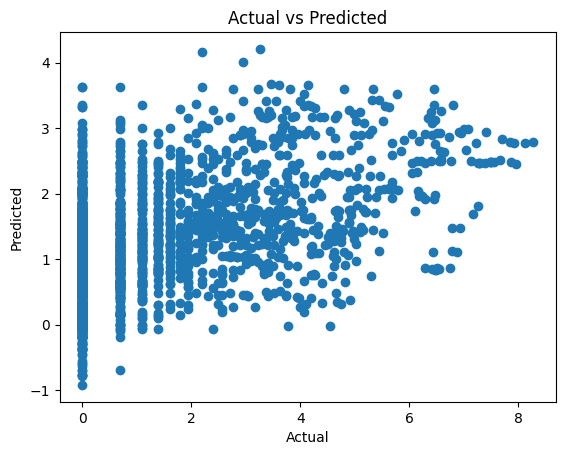

In [51]:
#(A) Actual vs Predicted Plot
df['predicted'] = model.predict(X)

plt.figure()
plt.scatter(df['log_attacks'], df['predicted'])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

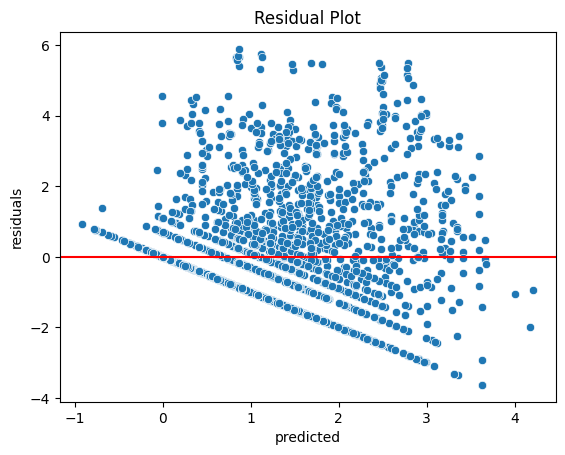

In [52]:
#(B) Residual Plot
df['residuals'] = df['log_attacks'] - df['predicted']

plt.figure()
sns.scatterplot(x=df['predicted'], y=df['residuals'])
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

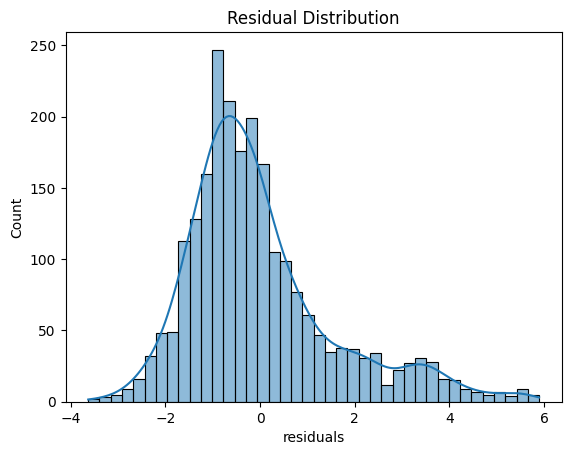

In [53]:
#(C) Residual Distribution
plt.figure()
sns.histplot(df['residuals'], kde=True)
plt.title("Residual Distribution")
plt.show()

In [71]:
#panel unit root test(stationarity)
#levin-lin-chu test

df=df.reset_index()

from statsmodels.tsa.stattools import adfuller

variables = ['log_attacks', 'rule of law', 'control of corruption',
             'voice and accountability', 'regulatory quality',
             'government effectiveness', 'political stability']

for var in variables:
    print(f"\nVariable: {var}")
    
    for country in df['country'].unique():
        series = df[df['country'] == country][var].dropna()
        
        # Skip if too small or constant
        if len(series) > 5 and series.nunique() > 1:
            try:
                result = adfuller(series)
                print(f"{country}: p-value = {result[1]:.4f}")
            except:
                continue
        else:
            print(f"{country}: Skipped (constant or insufficient data)")


Variable: log_attacks
afghanistan: p-value = 0.5780
albania: p-value = 0.2791
algeria: p-value = 1.0000
angola: p-value = 0.9935
argentina: p-value = 0.0465
australia: p-value = 1.0000
austria: p-value = 0.4960
azerbaijan: p-value = 0.0134
bahrain: p-value = 0.3779
bangladesh: p-value = 0.2917
barbados: Skipped (constant or insufficient data)
belarus: p-value = 0.1712
belgium: p-value = 0.0897
belize: p-value = 0.1934
benin: p-value = 0.9232
bhutan: p-value = 0.0011
bolivia: p-value = 0.0038
bosnia and herzegovina: p-value = 0.8371
botswana: Skipped (constant or insufficient data)
brazil: p-value = 0.7721
bulgaria: p-value = 0.0022
burkina faso: p-value = 0.9518
burundi: p-value = 0.1043
cambodia: p-value = 0.2511
cameroon: p-value = 1.0000
canada: p-value = 0.9030
central african republic: p-value = 0.1985
chad: p-value = 0.6748
chile: p-value = 0.9936
china: p-value = 0.1587
colombia: p-value = 0.1050
costa rica: p-value = 0.0006
croatia: p-value = 0.0014
cuba: p-value = 0.0006
cypr

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


guyana: p-value = 0.9983
haiti: p-value = 0.9461
honduras: p-value = 0.0000
hungary: p-value = 0.0335
iceland: p-value = 0.5439
india: p-value = 0.5988
indonesia: p-value = 0.7097
iraq: p-value = 0.1491
ireland: p-value = 0.8853
israel: p-value = 0.0025
italy: p-value = 0.2834
jamaica: p-value = 0.0000
japan: p-value = 0.0043
jordan: p-value = 0.3120
kazakhstan: p-value = 0.7580
kenya: p-value = 0.6228
kuwait: p-value = 0.0022
latvia: p-value = 0.0002
lebanon: p-value = 0.6203
lesotho: p-value = 0.0000
liberia: p-value = 0.0000
libya: p-value = 0.2820
lithuania: p-value = 0.0014
luxembourg: Skipped (constant or insufficient data)
madagascar: p-value = 0.1614
malawi: p-value = 0.0269
malaysia: p-value = 0.3992
mali: p-value = 0.0000
malta: p-value = 0.1697
mauritania: p-value = 0.0000
mauritius: Skipped (constant or insufficient data)
mexico: p-value = 0.4469
moldova: p-value = 0.0000
montenegro: p-value = 0.0116
morocco: p-value = 0.0000
mozambique: p-value = 0.0608
myanmar: p-value = 

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


rwanda: p-value = 0.5303
saudi arabia: p-value = 0.6452
senegal: p-value = 0.0861
serbia: p-value = 0.0396
seychelles: Skipped (constant or insufficient data)
sierra leone: p-value = 0.1739
singapore: Skipped (constant or insufficient data)
south africa: p-value = 0.6636
spain: p-value = 0.6315
sri lanka: p-value = 0.2647
sudan: p-value = 0.0128
suriname: Skipped (constant or insufficient data)
sweden: p-value = 0.2594
switzerland: p-value = 0.0000
tajikistan: p-value = 0.1562
tanzania: p-value = 0.3386
thailand: p-value = 0.2345
timor-leste: Skipped (constant or insufficient data)
togo: Skipped (constant or insufficient data)
trinidad and tobago: p-value = 0.0000
tunisia: p-value = 0.5947
uganda: p-value = 0.0883
ukraine: p-value = 0.9879
united arab emirates: p-value = 0.0800
united kingdom: p-value = 0.3556
united states: p-value = 0.9520
uruguay: p-value = 0.0002
uzbekistan: p-value = 0.0000
zambia: p-value = 0.0000
zimbabwe: p-value = 0.0000

Variable: rule of law
afghanistan: Ski

...

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


georgia: p-value = 0.0000
germany: p-value = 0.6398
ghana: p-value = 0.0034
greece: p-value = 0.0646
guatemala: p-value = 0.3085
guinea: p-value = 0.5872
guyana: p-value = 0.0000
haiti: p-value = 0.3360
honduras: p-value = 0.0000
hungary: p-value = 0.0000
iceland: p-value = 0.0349
india: p-value = 0.3431
indonesia: p-value = 0.0000
iraq: p-value = 0.2808
ireland: p-value = 0.8258
israel: p-value = 0.9955
italy: p-value = 0.3509
jamaica: p-value = 0.9523
japan: p-value = 0.6432
jordan: p-value = 0.0300
kazakhstan: p-value = 0.2447
kenya: p-value = 0.0665
kuwait: p-value = 0.8804
latvia: p-value = 0.4945
lebanon: p-value = 0.3008
lesotho: p-value = 0.6444
liberia: p-value = 0.0003
libya: p-value = 0.9115


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


lithuania: p-value = 0.4850
luxembourg: Skipped (constant or insufficient data)
madagascar: p-value = 0.4138
malawi: p-value = 0.4276
malaysia: p-value = 0.2775
mali: p-value = 0.3172
malta: p-value = 0.7119
mauritania: p-value = 0.9206
mauritius: p-value = 0.2707
mexico: p-value = 0.2340
moldova: p-value = 0.2194
montenegro: p-value = 0.1934
morocco: p-value = 0.0328
mozambique: p-value = 0.9919
myanmar: p-value = 0.4515
namibia: p-value = 0.3929
nepal: p-value = 0.0812
netherlands: p-value = 0.0001
new zealand: p-value = 0.7620
nicaragua: p-value = 0.0000
niger: p-value = 0.9800
nigeria: p-value = 0.3266
north macedonia: p-value = 0.4529
norway: Skipped (constant or insufficient data)
pakistan: p-value = 0.9625
panama: p-value = 0.4579
papua new guinea: p-value = 0.6157
paraguay: p-value = 0.0000
peru: p-value = 0.4879
philippines: p-value = 1.0000
poland: p-value = 0.0281
portugal: p-value = 0.0000
qatar: p-value = 0.0000
romania: p-value = 0.3081
rwanda: Skipped (constant or insuff

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


In [58]:
#heteroskedasticity

from linearmodels.panel import PanelOLS

y = df['log_attacks']
X = df[['rule of law', 'control of corruption',
        'voice and accountability', 'regulatory quality',
        'government effectiveness', 'political stability']]

X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True)
results = model.fit()

print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:            log_attacks   R-squared:                        0.0609
Estimator:                   PanelOLS   R-squared (Between):              0.0258
No. Observations:                2326   R-squared (Within):               0.0609
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.0357
Time:                        04:40:56   Log-likelihood                   -2888.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      23.574
Entities:                         137   P-value                           0.0000
Avg Obs:                       16.978   Distribution:                  F(6,2183)
Min Obs:                       9.0000                                           
Max Obs:                       19.000   F-statistic (robust):             23.574
                            

In [74]:
#Autocorrelation (Wooldridge Test)

import statsmodels.api as sm

# Create lag properly (IMPORTANT: correct column name)
df['log_attack_lag1'] = df.groupby('country')['log_attacks'].shift(1)

# First difference
df['log_attack_diff'] = df.groupby('country')['log_attacks'].diff()

# Combine into one dataset and drop NA together
df_test = df[['log_attack_diff', 'log_attack_lag1']].dropna()

# Define variables
y = df_test['log_attack_diff']
X = sm.add_constant(df_test['log_attack_lag1'])

# Run model
model_auto = sm.OLS(y, X).fit()

print(model_auto.summary())

                            OLS Regression Results                            
Dep. Variable:        log_attack_diff   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     64.01
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.99e-15
Time:                        04:52:08   Log-Likelihood:                -2404.6
No. Observations:                2189   AIC:                             4813.
Df Residuals:                    2187   BIC:                             4825.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.1311      0.019     

In [61]:
#Hausman Test

from linearmodels.panel import RandomEffects

fe_model = PanelOLS(y, X, entity_effects=True).fit()
re_model = RandomEffects(y, X).fit()

from linearmodels.panel import compare
print(compare({'FE': fe_model, 'RE': re_model}))

                       Model Comparison                       
                                          FE                RE
--------------------------------------------------------------
Dep. Variable                    log_attacks       log_attacks
Estimator                           PanelOLS     RandomEffects
No. Observations                        2326              2326
Cov. Est.                         Unadjusted        Unadjusted
R-squared                             0.0609            0.0629
R-Squared (Within)                    0.0609            0.0573
R-Squared (Between)                   0.0258            0.1393
R-Squared (Overall)                   0.0357            0.1207
F-statistic                           23.574            25.959
P-value (F-stat)                      0.0000            0.0000
==========================     =============   ===============
const                                 1.2061            1.7471
                                    (5.5977)          (

In [63]:
#Granger Causality

from statsmodels.tsa.stattools import grangercausalitytests

# Example: governance_index → log_attack
data_gc = df[['log_attacks', 'governance_index']].dropna()

grangercausalitytests(data_gc, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.2286  , p=0.2678  , df_denom=2322, df_num=1
ssr based chi2 test:   chi2=1.2302  , p=0.2674  , df=1
likelihood ratio test: chi2=1.2299  , p=0.2674  , df=1
parameter F test:         F=1.2286  , p=0.2678  , df_denom=2322, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5804  , p=0.5598  , df_denom=2319, df_num=2
ssr based chi2 test:   chi2=1.1633  , p=0.5590  , df=2
likelihood ratio test: chi2=1.1630  , p=0.5591  , df=2
parameter F test:         F=0.5804  , p=0.5598  , df_denom=2319, df_num=2


{np.int64(1): ({'ssr_ftest': (np.float64(1.2286334180481386),
    np.float64(0.2677877656413947),
    np.float64(2322.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.2302207997252035),
    np.float64(0.267364102082125),
    np.int64(1)),
   'lrtest': (np.float64(1.2298954428333673),
    np.float64(0.2674273729126101),
    np.int64(1)),
   'params_ftest': (np.float64(1.2286334180499519),
    np.float64(0.26778776564112167),
    np.float64(2322.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.5803815792664225),
    np.float64(0.5597660366453598),
    np.float64(2319.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.163265882031191),
    np.float64(0.5589848316353955),
    np.int64(2)),
   'lrtest': (np.float64(1.1629748458599352),
    np.float64(0.5590661799566724),
    np.int64(2)),
   'params_ftest': (np.float64(0.5803815792668147),
    np.float64(0.5597660366452155),
    np.float64(2319.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
   

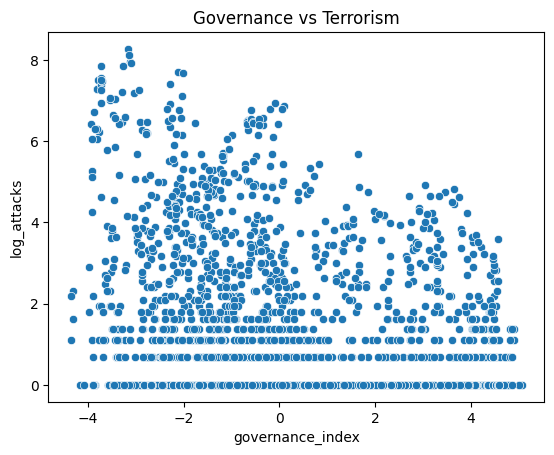

In [65]:
#Governance vs Terrorism

sns.scatterplot(x=df['governance_index'], y=df['log_attacks'])
plt.title("Governance vs Terrorism")
plt.show()

In [81]:
#Arellano–Bond (Difference GMM)

import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

# Set panel index
df = df.set_index(['country', 'year'])

# Create lags
df['lag1'] = df.groupby(level=0)['log_attacks'].shift(1)
df['lag2'] = df.groupby(level=0)['log_attacks'].shift(2)

# Drop NA
df = df.dropna()

# Dependent variable
y = df['log_attacks']

# Endogenous variable (lag1)
endog = df['lag1']

# Instrument (lag2)
instrument = df['lag2']

# Exogenous variables
exog = df[['rule of law', 'control of corruption',
           'voice and accountability', 'regulatory quality',
           'government effectiveness', 'political stability']]

exog = sm.add_constant(exog)

# IV-GMM style model
model_iv = IV2SLS(y, exog, endog, instrument).fit()

print(model_iv.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:            log_attacks   R-squared:                      0.8422
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8417
No. Observations:                2052   F-statistic:                  1.37e+04
Date:                Mon, Mar 23 2026   P-value (F-stat)                0.0000
Time:                        05:07:41   Distribution:                  chi2(7)
Cov. Estimator:                robust                                         
                                                                              
                                    Parameter Estimates                                     
                          Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------------
const                        0.2502     0.0679     3.6840     0.0002      0.1171      0.3

In [82]:
#Alternative: Using Governance Index

exog2 = df[['governance_index']]
exog2 = sm.add_constant(exog2)

model_iv2 = IV2SLS(y, exog2, endog, instrument).fit()

print(model_iv2.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:            log_attacks   R-squared:                      0.8400
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8399
No. Observations:                2052   F-statistic:                  1.36e+04
Date:                Mon, Mar 23 2026   P-value (F-stat)                0.0000
Time:                        05:08:04   Distribution:                  chi2(2)
Cov. Estimator:                robust                                         
                                                                              
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
const                0.0784     0.0189     4.1566     0.0000      0.0414      0.1153
governance_index    -0.0103 

In [84]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from scipy.stats import jarque_bera, pearsonr, spearmanr, ttest_ind, f_oneway
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [85]:
#Normality Test (Jarque-Bera — Best for Large Data)

variables = ['log_attacks', 'rule of law', 'control of corruption',
             'voice and accountability', 'regulatory quality',
             'government effectiveness', 'political stability']

for var in variables:
    stat, p = jarque_bera(df[var].dropna())
    print(f"{var}: JB p-value = {p}")

log_attacks: JB p-value = 8.923447919996403e-204
rule of law: JB p-value = 4.6292614781355953e-23
control of corruption: JB p-value = 1.853784503925257e-36
voice and accountability: JB p-value = 1.632429647028669e-17
regulatory quality: JB p-value = 1.9109079088455594e-15
government effectiveness: JB p-value = 1.5427661962893388e-27
political stability: JB p-value = 2.2247118142280105e-10


In [87]:
#Correlation Significance (Pearson)

for var in variables[1:]:
    corr, p = pearsonr(df['log_attacks'], df[var])
    print(f"log_attack vs {var}: Corr={corr:.3f}, p-value={p}")

log_attack vs rule of law: Corr=-0.200, p-value=5.357996876563952e-20
log_attack vs control of corruption: Corr=-0.193, p-value=1.3002677658829706e-18
log_attack vs voice and accountability: Corr=-0.176, p-value=9.623167611938765e-16
log_attack vs regulatory quality: Corr=-0.176, p-value=1.1368318715821046e-15
log_attack vs government effectiveness: Corr=-0.074, p-value=0.0008326513107551725
log_attack vs political stability: Corr=-0.386, p-value=9.423352300481164e-74


In [ ]:
#Rank Correlation (Spearman — Robust)

for var in variables[1:]:
    corr, p = spearmanr(df['log_attacks'], df[var])
    print(f"Spearman log_attack vs {var}: Corr={corr:.3f}, p={p}")

Spearman log_attack vs rule of law: Corr=-0.155, p=1.69971625606367e-12
Spearman log_attack vs control of corruption: Corr=-0.158, p=5.244817723104366e-13
Spearman log_attack vs voice and accountability: Corr=-0.127, p=6.869088346574032e-09
Spearman log_attack vs regulatory quality: Corr=-0.126, p=1.0915633231214706e-08
Spearman log_attack vs government effectiveness: Corr=-0.019, p=0.3783789505744676
Spearman log_attack vs political stability: Corr=-0.324, p=1.6295607067778253e-51


In [90]:
#Rank Correlation (Spearman — Robust)

df['gov_dummy'] = np.where(df['governance_index'] > df['governance_index'].median(), 1, 0)

group_high = df[df['gov_dummy'] == 1]['log_attacks']
group_low = df[df['gov_dummy'] == 0]['log_attacks']

t_stat, p = ttest_ind(group_high, group_low, equal_var=False)
print("T-test p-value:", p)

T-test p-value: 4.934553235942484e-22


In [91]:
#ANOVA (3 Governance Groups)

df['gov_group'] = pd.qcut(df['governance_index'], 3, labels=['Low','Medium','High'])

g1 = df[df['gov_group'] == 'Low']['log_attacks']
g2 = df[df['gov_group'] == 'Medium']['log_attacks']
g3 = df[df['gov_group'] == 'High']['log_attacks']

f_stat, p = f_oneway(g1, g2, g3)
print("ANOVA p-value:", p)

ANOVA p-value: 1.855729934019269e-23


In [94]:
#Fixed Effects with Time Effects (VERY IMPORTANT)

df=df.reset_index()

from linearmodels.panel import PanelOLS

df = df.set_index(['country', 'year'])

model_tw = PanelOLS(y, X, entity_effects=True, time_effects=True)
results_tw = model_tw.fit(cov_type='clustered', cluster_entity=True)

print(results_tw.summary)

ValueError: dependent and exog must have the same number of observations. The number of observations in dependent is 2052, and the number of observations in exog is 4378.

In [95]:
#Poisson Regression

import statsmodels.api as sm

poisson_model = sm.GLM(y_clean, X_clean, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

NameError: name 'y_clean' is not defined

In [96]:
#Negative Binomial (Better if overdispersion)

nb_model = sm.GLM(y_clean, X_clean, family=sm.families.NegativeBinomial()).fit()
print(nb_model.summary())

NameError: name 'y_clean' is not defined

In [97]:
#Quantile Regression

import statsmodels.formula.api as smf

qr = smf.quantreg('log_attacks ~ governance_index', df.reset_index())
res_qr = qr.fit(q=0.5)   # median

print(res_qr.summary())

                         QuantReg Regression Results                          
Dep. Variable:            log_attacks   Pseudo R-squared:             0.008629
Model:                       QuantReg   Bandwidth:                      0.6275
Method:                 Least Squares   Sparsity:                        3.066
Date:                Mon, 23 Mar 2026   No. Observations:                 2052
Time:                        05:18:21   Df Residuals:                     2050
                                        Df Model:                            1
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.5637      0.034     16.654      0.000       0.497       0.630
governance_index    -0.1198      0.015     -7.892      0.000      -0.150      -0.090


In [98]:
#Interaction Effects

df['interaction'] = df['control of corruption'] * df['political stability']

X_int = df[['control of corruption', 'political stability', 'interaction']]
X_int = sm.add_constant(X_int)

model_int = sm.OLS(y, X_int).fit()
print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:            log_attacks   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     166.5
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.47e-96
Time:                        05:19:19   Log-Likelihood:                -3917.8
No. Observations:                2052   AIC:                             7844.
Df Residuals:                    2048   BIC:                             7866.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     4.02

In [99]:
#Non-Linear Effects

df['gov_sq'] = df['governance_index'] ** 2

X_nl = sm.add_constant(df[['governance_index', 'gov_sq']])
model_nl = sm.OLS(y, X_nl).fit()

print(model_nl.summary())

                            OLS Regression Results                            
Dep. Variable:            log_attacks   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     77.39
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.97e-33
Time:                        05:20:05   Log-Likelihood:                -4067.0
No. Observations:                2052   AIC:                             8140.
Df Residuals:                    2049   BIC:                             8157.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.0773      0.053  